In [1]:
import jax
print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX devices: [CudaDevice(id=0)]
Default backend: gpu


W1119 12:42:04.754099    1567 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1119 12:42:04.762485    1465 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [2]:
# Enable autoreload of local Python modules (e.g., models)
%load_ext autoreload
%autoreload 2

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time

# local imports
import models.models1 as models
import util.generation as generation


In [6]:
# initialize the jax random key
key = jax.random.key(0)

# Load data

In [7]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("./data/text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [8]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [9]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [10]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

jodalv drums one nine nine three one nine nine nine brynjard tristan bass one nine nine four one nine nine six nagash bass one n

of arizona johnson won four eight six electoral votes to goldwater s five two and almost carried goldwater s arizona which gave 

ment amplifiers its critical components are active devices such as vacuum tubes or transistors class amplifiers are commonly cla

ls as their sole method of accepting cashless payment canada main article interac canada has a nation wide eftpos system called 

each of which may be informally referred to as a standard in and of itself there are currently one five parts introduction while



# Create a basic Transformer model

In [ ]:
def create_train_state(
    rng,
    vocab_size=27,
    d_model=64,
    n_layers=6,
    n_heads=8,
    max_len=128,
    dropout=0.1,
):
    # create a basic Transformer model
    model = models.DecoderOnlyTransformer(
        vocab_size=vocab_size,
        d_model=d_model,
        n_layers=n_layers,
        n_heads=n_heads,
        n_kv_heads=1,     # explicit, you can change if you want GQA
        max_len=max_len,
        dropout=dropout,
    )
    # create a dummy input for initialization
    dummy = jnp.zeros((1, min(16, max_len)), dtype=jnp.int32)
    # pass the dummy input to the model to initialize the parameters
    params = model.init({"params": rng}, dummy)["params"]
    return model, params


In [ ]:
# # vocab size
# vocab_size= len(char_set)

# # internal model dimensions
# d_model=256

# # number of attention heads
# n_heads=8

# # number of Transformer layers
# n_layers=2

# # maximum sequence length
# max_len=128

# model, params = create_train_state(key, vocab_size, d_model, n_layers, n_heads, max_len)

In [13]:
# compute the number of parameters
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters: {count_params(params):_}")

Number of parameters: 1_350_658


In [14]:
# sanity check: create a batch of data & run a forward pass
B, T = 4, 32
batch = jax.random.randint(
    key=key,
    shape=(B, T), minval=0, maxval=len(char_set))
logits = model.apply({"params": params}, batch)

print("batch shape:", batch.shape)  # (B, T)
print("logits shape:", logits.shape)  # (B, T, vocab_size)

batch shape: (4, 32)
logits shape: (4, 32, 27)


# Loss function

In [15]:
@jax.jit
def loss_and_metrics(logits, targets):
    """Compute cross-entropy loss and accuracy.

    Assumes `targets` contains only valid integer class ids in [0, V-1] (no -1 ignore tokens).

    Args:
      logits: (B, T, V) float array of unnormalized scores.
      targets: (B, T) integer array with ground-truth class ids.

    Returns:
      loss: scalar average cross-entropy over all positions.
      metrics: dict with keys "loss" and "acc" (both scalars).
    """
    # Flatten batch/time dims so optax works on shape (N, V) and (N,)
    vocab = logits.shape[-1]
    flat_logits = logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)

    # Per-position cross-entropy, then mean over all positions
    per_pos = optax.softmax_cross_entropy_with_integer_labels(flat_logits, flat_targets)
    loss = per_pos.mean()

    # prediction over all positions
    preds = jnp.argmax(logits, axis=-1)  # (B, T)
    
    # compute accuracy over only the last position
    is_match = preds == targets
    
    # Accuracy over all positions
    acc_all = jnp.mean(is_match.astype(jnp.float32))
    
    # Accuracy over only last position
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:,-1])

    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}

# Optimization step:

In [16]:
# create an update function
def train_step(params, opt_state, x, y, tx):
    """Single optimization step using optax optimizer.

    Args:
      params: pytree of model parameters.
      opt_state: optax optimizer state corresponding to `params`.
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
      tx: optax.GradientTransformation (already initialized).

    Returns:
      new_params: updated parameters after one gradient step.
      new_opt_state: updated optimizer state.
      metrics: dict of scalar metrics (loss, acc).
    """
    def loss_fn(params):
        logits = model.apply({"params": params}, x)
        loss, metrics = loss_and_metrics(logits, y)
        return loss, metrics

    # compute gradients (loss is scalar, metrics is auxiliary)
    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # optax update: compute parameter updates and new optimizer state
    updates, new_opt_state = tx.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, metrics

# jit: last argument should be static because it is an object
train_step = jax.jit(train_step, static_argnames=("tx",))

# Batch creation:

In [17]:
# create a batch from the training data
def get_batch(text_int, B, T):
    """Create a random batch of data from text_int.

    Args:
      text_int: 1D array of token ids.
      B: batch size (number of sequences).
      T: sequence length (number of tokens per sequence).

    Returns:
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
    """
    # choose random starting indices for each sequence in the batch
    ix = np.random.randint(0, len(text_int) - T, size=B)
    # inputs are text from i to i+T
    x = np.stack([text_int[i:i+T] for i in ix])
    # targets are text from i+1 to i+T+1
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

In [ ]:
import itertools

vocab_size = len(char_set)
max_len = 128

def run_single_config(
    config,
    train_text_int,
    test_text_int,
    base_key,
    niter_search=5000,
    B=128,
    T=32,
    B_test=512,
    T_test=32,
    eval_every=200,
):
    """
    Train briefly with one hyperparameter config and return best validation loss.
    """
    print("\n=== Running config:", config, "===\n")

    # Split RNG for init vs training
    key_init, key_train = jax.random.split(base_key)

    # 1. Build model + params for THIS config
    model, params = create_train_state(
        key_init,
        vocab_size=config["vocab_size"],
        d_model=config["d_model"],
        n_layers=config["n_layers"],
        n_heads=config["n_heads"],
        max_len=config["max_len"],
        dropout=config["dropout"],
    )

    # 2. Build optimizer for THIS config
    if config["opt"] == "adamw":
        lr = config["learning_rate"]
        tx = optax.adamw(learning_rate=lr, weight_decay=config["weight_decay"])
    else:
        lr = config["learning_rate"]
        tx = optax.adam(learning_rate=lr)

    opt_state = tx.init(params)

    # 3. Local jitted train_step that closes over model + tx
    @jax.jit
    def train_step_local(params, opt_state, x, y):
        def loss_fn(p):
            logits = model.apply({"params": p}, x)
            loss, metrics = loss_and_metrics(logits, y)
            return loss, metrics

        (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        updates, new_opt_state = tx.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, metrics

    best_test_loss = None

    for it in range(1, niter_search + 1):
        # training batch
        x, y = get_batch(train_text_int, B, T)
        params, opt_state, metrics = train_step_local(params, opt_state, x, y)

        if it % eval_every == 0 or it == niter_search:
            # validation batch
            x_test, y_test = get_batch(test_text_int, B_test, T_test)
            logits_test = model.apply({"params": params}, x_test)
            test_loss, test_metrics = loss_and_metrics(logits_test, y_test)

            test_loss_val = float(test_loss)
            acc_last = float(metrics["acc_last"])
            test_acc_last = float(test_metrics["acc_last"])

            print(
                f"[it {it:5d}] "
                f"train_loss={float(metrics['loss']):.4f} "
                f"test_loss={test_loss_val:.4f} "
                f"train_acc_last={100*acc_last:.1f}% "
                f"test_acc_last={100*test_acc_last:.1f}%"
            )

            if best_test_loss is None or test_loss_val < best_test_loss:
                best_test_loss = test_loss_val

    return best_test_loss, params, model

In [ ]:
# ---- hyperparameter search space ----

model_configs = [
    {"d_model": 256, "n_layers": 2, "n_heads": 8},
    {"d_model": 384, "n_layers": 4, "n_heads": 8},
]

dropouts = [0.0, 0.1]
learning_rates = [1e-3, 3e-4]
opts = ["adam", "adamw"]
weight_decays = [1e-2]  # only used for adamw

search_space = []

for mc in model_configs:
    for drop in dropouts:
        for lr in learning_rates:
            for opt in opts:
                if opt == "adam":
                    cfg = {
                        "vocab_size": vocab_size,
                        "max_len": max_len,
                        "d_model": mc["d_model"],
                        "n_layers": mc["n_layers"],
                        "n_heads": mc["n_heads"],
                        "dropout": drop,
                        "learning_rate": lr,
                        "opt": "adam",
                        "weight_decay": 0.0,
                    }
                    search_space.append(cfg)
                else:  # adamw
                    for wd in weight_decays:
                        cfg = {
                            "vocab_size": vocab_size,
                            "max_len": max_len,
                            "d_model": mc["d_model"],
                            "n_layers": mc["n_layers"],
                            "n_heads": mc["n_heads"],
                            "dropout": drop,
                            "learning_rate": lr,
                            "opt": "adamw",
                            "weight_decay": wd,
                        }
                        search_space.append(cfg)

print("Total configs in search space:", len(search_space))

In [ ]:
best_config = None
best_loss = None
best_model = None
best_params = None

base_key = jax.random.PRNGKey(0)

for i, config in enumerate(search_space):
    print(f"\n##### Config {i+1}/{len(search_space)} #####")
    key_i = jax.random.fold_in(base_key, i)

    test_loss, params_cfg, model_cfg = run_single_config(
        config,
        train_text_int=train_text_int,
        test_text_int=test_text_int,
        base_key=key_i,
        niter_search=1000,   # keep small so it’s fast
        B=128,
        T=32,
        B_test=512,
        T_test=32,
        eval_every=200,
    )

    print(f"Config {i+1} finished with best_test_loss={test_loss:.4f}")

    if best_loss is None or test_loss < best_loss:
        best_loss = test_loss
        best_config = config
        best_model = model_cfg
        best_params = params_cfg

print("\n=== GRID SEARCH DONE ===")
print("Best config:", best_config)
print("Best validation loss:", best_loss)

In [ ]:
print("\nUsing best config for full training:", best_config)

d_model = best_config["d_model"]
n_layers = best_config["n_layers"]
n_heads = best_config["n_heads"]
dropout = best_config["dropout"]
learning_rate = best_config["learning_rate"]
opt_type = best_config["opt"]
weight_decay = best_config["weight_decay"]

# new RNG for final training
key = jax.random.PRNGKey(42)
model, params = create_train_state(
    key,
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    max_len=max_len,
    dropout=dropout,
)

# count final params (optional)
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters (best config): {count_params(params):_}")

# optimizer for final run
if opt_type == "adamw":
    tx = optax.adamw(learning_rate=learning_rate, weight_decay=weight_decay)
else:
    tx = optax.adam(learning_rate=learning_rate)

opt_state = tx.init(params)
print(f"Initialized optimizer: {opt_type} lr={learning_rate}")

# Optimizer creation:

In [ ]:
# # define optax optimizer
# learning_rate = 0.001
# # Create Adam optimizer (Optax)
# tx = optax.adam(learning_rate=learning_rate)
# # Initialize optimizer state for current params
# opt_state = tx.init(params)
# print(f"Initialized optimizer: Adam lr={learning_rate}")

Initialized optimizer: Adam lr=0.001


In [ ]:
niter = 50000
B, T = 128, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()

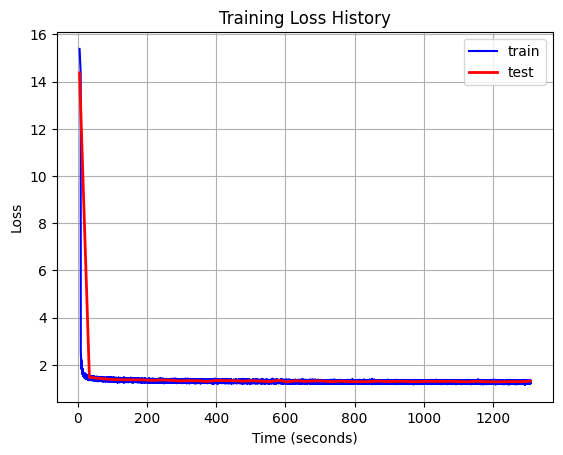

In [21]:
# plot the loss history
import matplotlib.pyplot as plt
plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

In [22]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
# prompt_int = encode(prompt.lower())
prompt_int = jnp.array([ [char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generation.generate_tokens(model, params, rng, prompt_int, gen_len, block_size=64, 
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 1000)
generated text:
hello my fritir s cotwo werabl sho ide on cle irteman bds lopunaatiou onc aeo coaaeireaioaoe ulleoaini meor a iaaeunaetha s gxoandril aa kiryustyan acin wha jiireishaiin thad taanoorackharathee te ibiunou streoo ndioust foerart re ari len m teppp toeraeiiennge hecolets rieeabeen on coulespamoo moo pl cabeu s t clio pestolsisoea p eltulocier siel boone baa ceuroaeis izeevinirump we tenaaehera anteenaeewallioretaloahtetaedaat encasin avinaareulabiniini sceta n porettiu ande plandes ihigonizond on icd andies lakavo haaeel shiaiieleu ndole s c p estg aepo rrotoam ia coranar rlesuurinedeemachwik faaeoyohiiperorevi rrris rooie dianoupphonde and andesarel rathin on onl aiaiim sian braaau idy ana deariaaier coo aonndetiiioun bine opaaongroawarmila spore blar hi iean houlll ait abaosp muth tendhe s pada waiwinar s caeuneus cathe opap brorfa aonaropoon son thero mbreachiiieun mexxreph oooline rolieaeita ous nice e mi ta t wini anwiiiaeleenieaoaostev